In [1]:
import os
import json

import numpy as np
import rasterio
from rasterio.mask import mask
import matplotlib.pyplot as plt

In [2]:
# project paths
aoi_path = r"data/aoi.geojson"

bands_10m_path = r"data/downloads/S2A_MSIL2A_20260726T093051_N0512_R136_T34UEB_20260726T161013.SAFE/GRANULE/L2A_T34UEB_A057934_20260726T093050/IMG_DATA/R10m/"
bands_10m_clipped_path = os.path.join(bands_10m_path, "clipped")

### 10 m resolution rasters

In [3]:
# .jp2 -> JPEG 2000
# .jp2 file contains a raster: a grid of pixels where each pixel has a numerical value
# representing the measured or processed reflectance for a specific spectral band
# .jp2 files represent different spectral bands from the same Sentinel-2 observation
# spectral band is usually a single-band raster, i.e. a large matrix of pixel values

bands_10m = [filename for filename in os.listdir(bands_10m_path) if filename.endswith(".jp2")]
bands_10m

['T34UEB_20260726T093051_AOT_10m.jp2',
 'T34UEB_20260726T093051_B02_10m.jp2',
 'T34UEB_20260726T093051_B03_10m.jp2',
 'T34UEB_20260726T093051_B04_10m.jp2',
 'T34UEB_20260726T093051_B08_10m.jp2',
 'T34UEB_20260726T093051_TCI_10m.jp2',
 'T34UEB_20260726T093051_WVP_10m.jp2']

In [4]:
# clip rasters to the AOI
with open(aoi_path, "r") as f:
    aoi = json.load(f)

for band in bands_10m:
    band_path = os.path.join(bands_10m_path, band)
    with rasterio.open(band_path) as src:
        # crs - coordinate reference system - układ odniesienia współrzędnych
        clipped, transform = mask(
            src,
            [aoi],
            crop=True,
            filled=False,
        	all_touched=True
        )
    
        profile = src.profile.copy()
        profile.update(
            height=clipped.shape[1],
            width=clipped.shape[2],
            transform=transform
        )

        band_clipped_path = os.path.join(bands_10m_clipped_path, band)
        
        with rasterio.open(band_clipped_path, "w", **profile) as dst:
            dst.write(clipped)

In [5]:
bands_clipped_10m = [os.path.join(bands_10m_clipped_path, filename) for filename in os.listdir(bands_10m_clipped_path) if filename.endswith(".jp2")]

In [6]:
# read all images with rasterio library
images = []

for i in bands_clipped_10m:
    with rasterio.open(i, "r") as f:
        band = f.read(1)
        images.append(band)

In [7]:
# stack images as n dimensional array
# convert to float for calculations
arrImages_10m = np.stack(images, dtype=float)

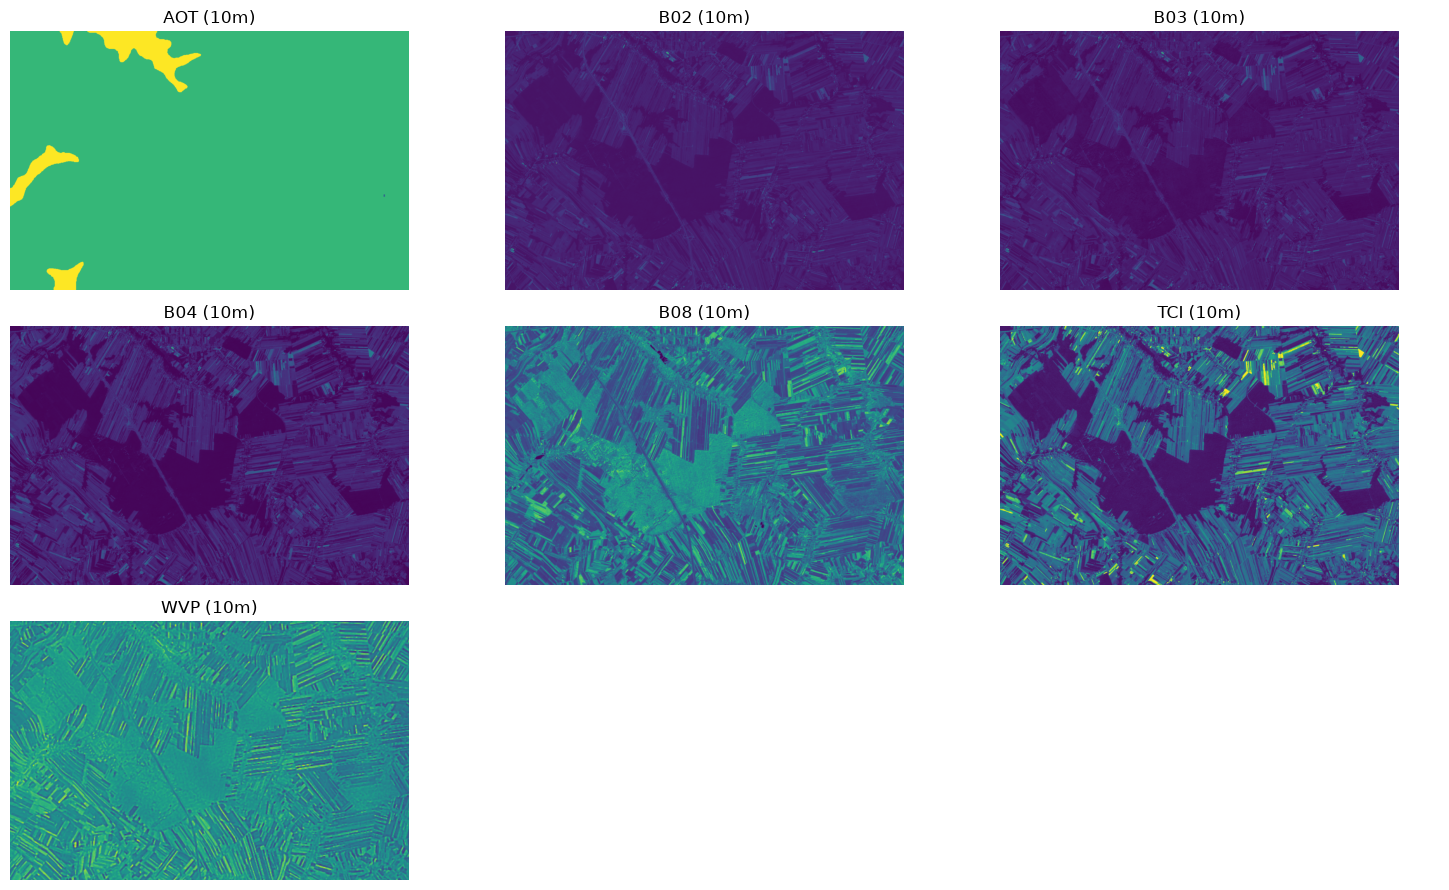

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(15, 9))
axes = axes.ravel()

for i, band in enumerate(arrImages_10m):
    axes[i].imshow(band)
    axes[i].set_title(f"{bands_10m[i][-11:-8]} ({bands_10m[i][-7:-4]})")
    axes[i].set_axis_off()
axes[7].axis("off")
axes[8].axis("off")
plt.tight_layout()

## Normalized Difference Vegetation Index (NDVI)

In [9]:
# get the RED band
# divide values by 10,000 to convert scaled integer values to reflectance values
b04 = arrImages_10m[3]
b04_ref = b04 / 10000

In [10]:
# the B04 properties
print(f"B04 shape: {b04_ref.shape}")
print(f"B04 dtype: {b04_ref.dtype}")
print(f"B04 min: {np.nanmin(b04_ref)}")
print(f"B04 max: {np.nanmax(b04_ref)}")

B04 shape: (896, 1382)
B04 dtype: float64
B04 min: 0.1101
B04 max: 0.8225


In [11]:
# get the NIR band
# divide values by 10,000 to convert scaled integer values to reflectance values
b08 = arrImages_10m[4]
b08_ref = b08 / 10000

In [12]:
# the B08 properties
print(f"B08 shape: {b08_ref.shape}")
print(f"B08 dtype: {b08_ref.dtype}")
print(f"B08 min: {np.nanmin(b08_ref)}")
print(f"B08 max: {np.nanmax(b08_ref)}")

B08 shape: (896, 1382)
B08 dtype: float64
B08 min: 0.1167
B08 max: 0.8659


In [13]:
# calculate NDVI
numerator = b08_ref - b04_ref
denominator = b08_ref + b04_ref

ndvi = np.divide(numerator, denominator, out=np.full(arrImages_10m[3].shape, np.nan, dtype=np.float64), where=denominator != 0)

In [14]:
print("NDVI min:", np.nanmin(ndvi))
print("NDVI max:", np.nanmax(ndvi))
print("NDVI mean:", np.nanmean(ndvi))
print("NDVI median:", np.nanmedian(ndvi))

print(np.nanpercentile(ndvi, [1, 5, 25, 50, 75, 95, 99]))

NDVI min: -0.24981727817570532
NDVI max: 0.7178149291875199
NDVI mean: 0.3789497976816659
NDVI median: 0.382942176702884
[0.11093569 0.13230223 0.19708296 0.38294218 0.55870682 0.62736492
 0.65115952]


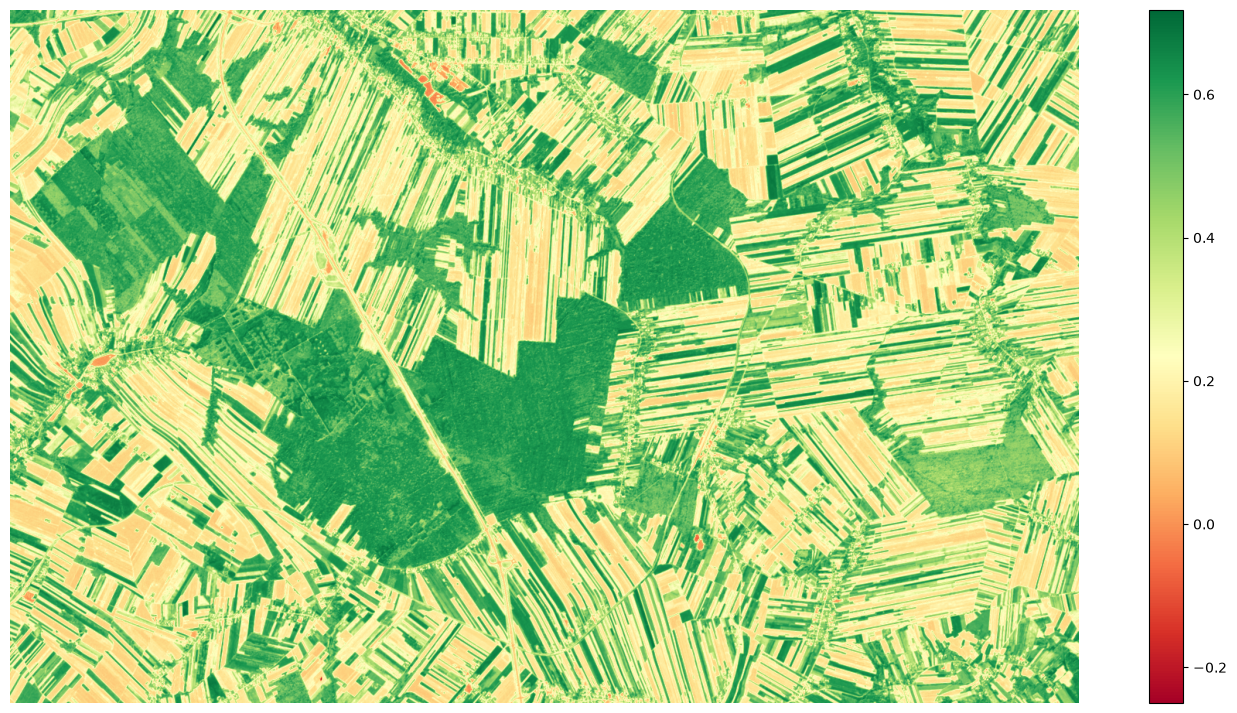

In [15]:
fig, ax = plt.subplots(figsize=(18, 9))

plt.imshow(ndvi, cmap="RdYlGn")
plt.colorbar()
ax.set_axis_off()
plt.savefig("docs/ndvi.png")

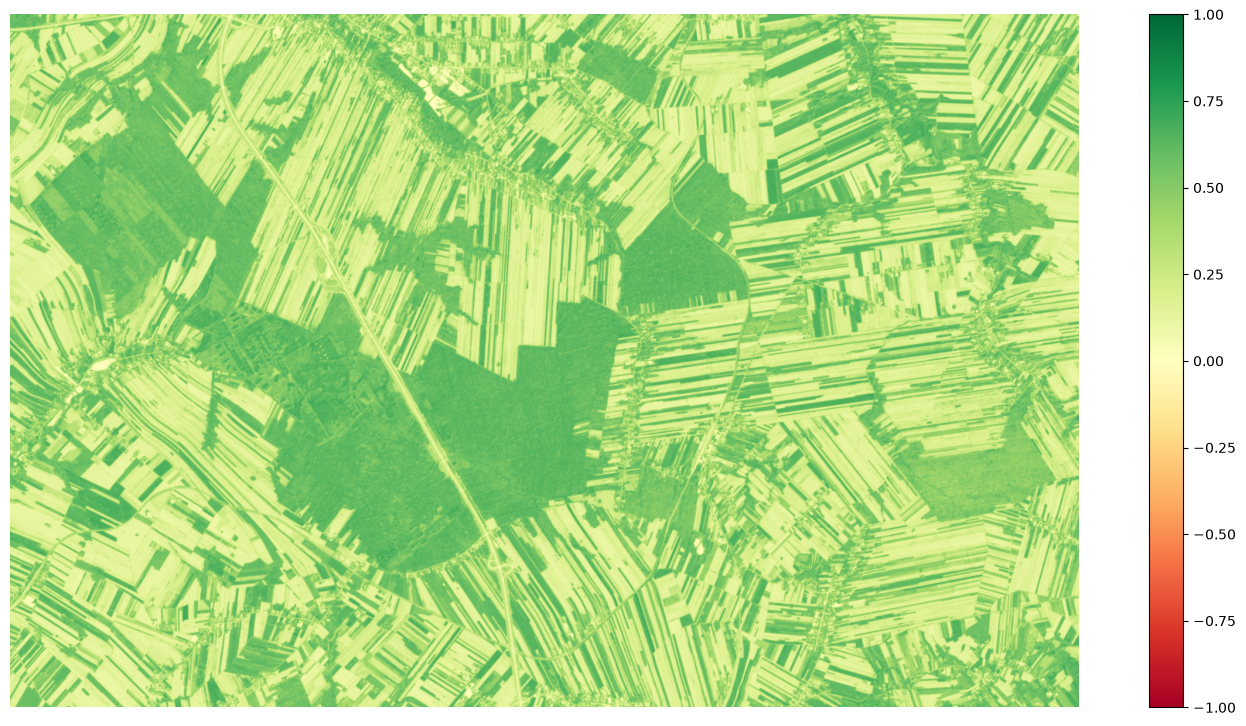

In [16]:
fig, ax = plt.subplots(figsize=(18, 9))

plt.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar()
ax.set_axis_off()
plt.savefig("docs/ndvi_comparison.png")

## Enhanced Vegetation Index (EVI)

In [17]:
# get the BLUE band
# divide values by 10,000 to convert scaled integer values to reflectance values
b02 = arrImages_10m[1]
b02_ref = b02 / 10000

In [18]:
# b02 properties
print(f"B02 shape: {b02_ref.shape}")
print(f"B02 dtype: {b02_ref.dtype}")
print(f"B02 min: {np.nanmin(b02_ref)}")
print(f"B02 max: {np.nanmax(b02_ref)}")

B02 shape: (896, 1382)
B02 dtype: float64
B02 min: 0.0874
B02 max: 0.7817


In [19]:
numerator = b08_ref - b04_ref
denominator = b08_ref + 6 * b04_ref - 7.5 * b02_ref + 1

evi = 2.5 * np.divide(numerator, denominator, out=np.full(b02.shape, np.nan, dtype=np.float64), where=denominator > 0.05)

In [20]:
print("EVI min:", np.nanmin(evi))
print("EVI max:", np.nanmax(evi))
print("EVI mean:", np.nanmean(evi))
print("EVI median:", np.nanmedian(evi))

print(np.nanpercentile(evi, [1, 5, 25, 50, 75, 95, 99]))

EVI min: -0.5921553693830925
EVI max: 3.0627352572145523
EVI mean: 0.4232844409511867
EVI median: 0.41023488063908803
[0.10285146 0.12226794 0.18692611 0.41023488 0.64412869 0.78144679
 0.86062633]


In [21]:
print("Pixels EVI > 1:", np.sum(evi > 1))
print("Pixels EVI > 2:", np.sum(evi > 2))
print("Total valid pixels:", np.sum(~np.isnan(evi)))

Pixels EVI > 1: 42
Pixels EVI > 2: 2
Total valid pixels: 1238268


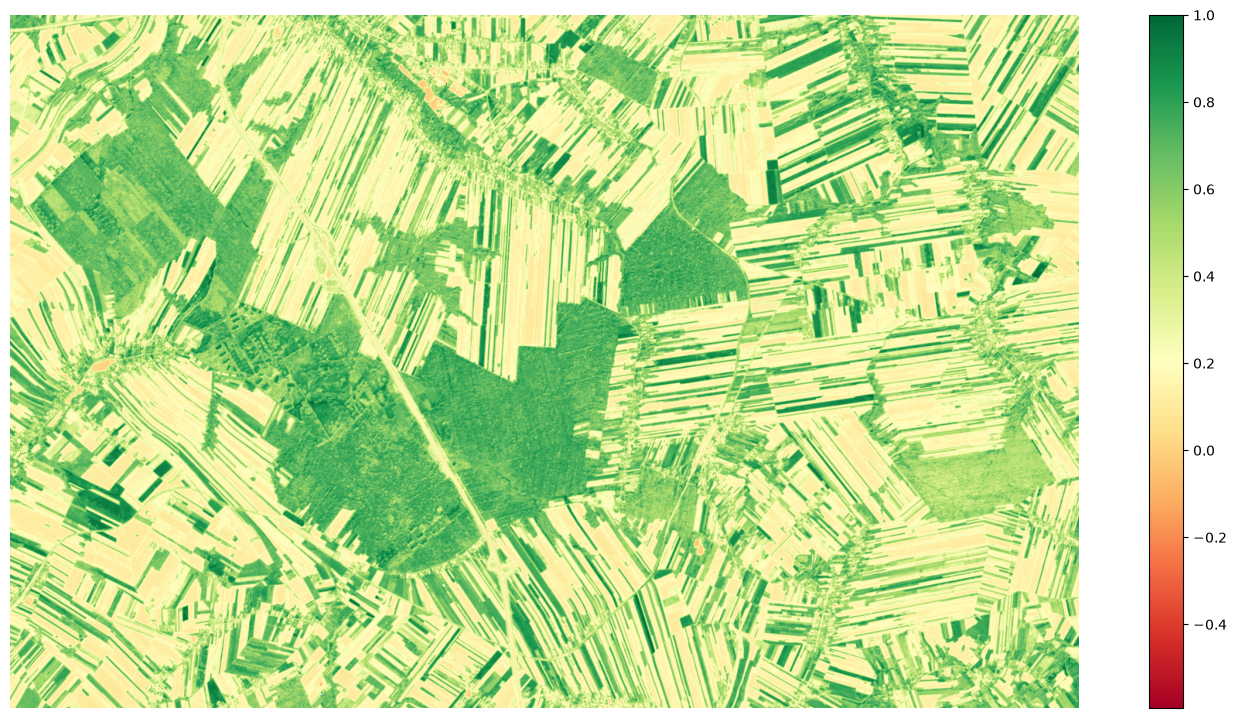

In [22]:
fig, ax = plt.subplots(figsize=(18, 9))

plt.imshow(evi, cmap="RdYlGn", vmax=1)
plt.colorbar()
ax.set_axis_off()
plt.savefig("docs/evi.png")

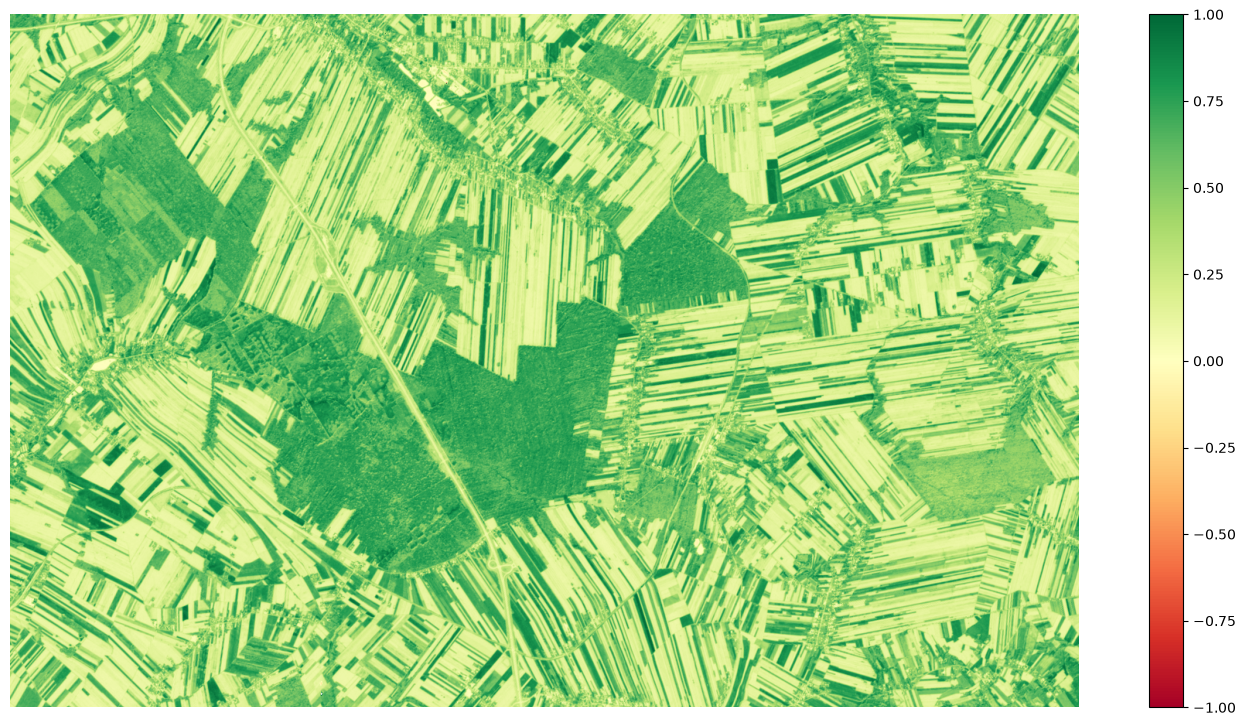

In [23]:
fig, ax = plt.subplots(figsize=(18, 9))

plt.imshow(evi, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar()
ax.set_axis_off()
plt.savefig("docs/evi_comparison.png")

In [24]:
# https://geopera.com/blog/remote-sensing-vegetation-indices
# https://www.agricolus.com/en/vegetation-indices-ndvi-ndmi/
# https://fotogrametria.agh.edu.pl/~tpirowsk/GIS4DSS/Pomocnik/04_Indeksy_spektralne_SDI.pdf